In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier
import matplotlib.pyplot as plt


def feature_importance_selector(indep_X, dep_Y, n):
    model = ExtraTreesClassifier(n_estimators=100, random_state=0)
    model.fit(indep_X, dep_Y)
    importances = pd.Series(model.feature_importances_, index=indep_X.columns)
    top_n = importances.nlargest(n).index
    return indep_X[top_n].values, top_n


def split_scalar(indep_X, dep_Y):
    X_train, X_test, y_train, y_test = train_test_split(
        indep_X, dep_Y, test_size=0.25, random_state=0
    )
    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test = sc.transform(X_test)
    return X_train, X_test, y_train, y_test


def cm_prediction(classifier, X_test):
    y_pred = classifier.predict(X_test)
    from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
    cm = confusion_matrix(y_test, y_pred)
    Accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)
    return classifier, Accuracy, report, X_test, y_test, cm


def logistic(X_train, y_train, X_test):
    from sklearn.linear_model import LogisticRegression
    classifier = LogisticRegression(random_state=0, max_iter=1000)
    classifier.fit(X_train, y_train)
    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test)
    return classifier, Accuracy, report, X_test, y_test, cm


def svm_linear(X_train, y_train, X_test):
    from sklearn.svm import SVC
    classifier = SVC(kernel='linear', random_state=0)
    classifier.fit(X_train, y_train)
    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test)
    return classifier, Accuracy, report, X_test, y_test, cm


def svm_NL(X_train, y_train, X_test):
    from sklearn.svm import SVC
    classifier = SVC(kernel='rbf', random_state=0)
    classifier.fit(X_train, y_train)
    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test)
    return classifier, Accuracy, report, X_test, y_test, cm


def Navie(X_train, y_train, X_test):
    from sklearn.naive_bayes import GaussianNB
    classifier = GaussianNB()
    classifier.fit(X_train, y_train)
    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test)
    return classifier, Accuracy, report, X_test, y_test, cm


def knn(X_train, y_train, X_test):
    from sklearn.neighbors import KNeighborsClassifier
    classifier = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
    classifier.fit(X_train, y_train)
    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test)
    return classifier, Accuracy, report, X_test, y_test, cm


def Decision(X_train, y_train, X_test):
    from sklearn.tree import DecisionTreeClassifier
    classifier = DecisionTreeClassifier(criterion='entropy', random_state=0)
    classifier.fit(X_train, y_train)
    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test)
    return classifier, Accuracy, report, X_test, y_test, cm


def random(X_train, y_train, X_test):
    from sklearn.ensemble import RandomForestClassifier
    classifier = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
    classifier.fit(X_train, y_train)
    classifier, Accuracy, report, X_test, y_test, cm = cm_prediction(classifier, X_test)
    return classifier, Accuracy, report, X_test, y_test, cm


def fi_Classification(acclog, accsvml, accsvmnl, accknn, accnav, accdes, accrf):
    dataframe = pd.DataFrame(
        index=['FeatureImportance'],
        columns=['Logistic', 'SVMl', 'SVMnl', 'KNN', 'Navie', 'Decision', 'Random']
    )
    for number, idex in enumerate(dataframe.index):
        dataframe.loc[idex, 'Logistic'] = acclog[number]
        dataframe.loc[idex, 'SVMl']     = accsvml[number]
        dataframe.loc[idex, 'SVMnl']    = accsvmnl[number]
        dataframe.loc[idex, 'KNN']      = accknn[number]
        dataframe.loc[idex, 'Navie']    = accnav[number]
        dataframe.loc[idex, 'Decision'] = accdes[number]
        dataframe.loc[idex, 'Random']   = accrf[number]
    return dataframe


In [2]:
dataset1 = pd.read_csv("prep.csv", index_col=None)
df2 = dataset1.copy()

df2 = pd.get_dummies(df2, drop_first=True)

indep_X = df2.drop('classification_yes', axis=1)
dep_Y = df2['classification_yes']

df2


,age,bp,al,su,bgr,bu,sc,sod,pot,hrmo,...,pc_normal,pcc_present,ba_present,htn_yes,dm_yes,cad_yes,appet_yes,pe_yes,ane_yes,classification_yes
0,2.000000,76.459948,3.0,0.0,148.112676,57.482105,3.077356,137.528754,4.627244,12.518156,...,False,False,False,False,False,False,True,True,False,True
1,3.000000,76.459948,2.0,0.0,148.112676,22.000000,0.700000,137.528754,4.627244,10.700000,...,True,False,False,False,False,False,True,False,False,True
2,4.000000,76.459948,1.0,0.0,99.000000,23.000000,0.600000,138.000000,4.400000,12.000000,...,True,False,False,False,False,False,True,False,False,True
3,5.000000,76.459948,1.0,0.0,148.112676,16.000000,0.700000,138.000000,3.200000,8.100000,...,True,False,False,False,False,False,True,False,True,True
4,5.000000,50.000000,0.0,0.0,148.112676,25.000000,0.600000,137.528754,4.627244,11.800000,...,True,False,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,51.492308,70.000000,0.0,0.0,219.000000,36.000000,1.300000,139.000000,3.700000,12.500000,...,True,False,False,False,False,False,True,False,False,True
395,51.492308,70.000000,0.0,2.0,220.000000,68.000000,2.800000,137.528754,4.627244,8.700000,...,True,False,False,True,True,False,True,False,True,True
396,51.492308,70.000000,3.0,0.0,110.000000,115.000000,6.000000,134.000000,2.700000,9.100000,...,True,False,False,True,True,False,False,False,False,True
397,51.492308,90.000000,0.0,0.0,207.000000,80.000000,6.800000,142.000000,5.500000,8.500000,...,True,False,False,True,True,False,True,False,True,True


Selected features: ['htn_yes', 'hrmo', 'dm_yes', 'sg_c', 'sg_b', 'al', 'pcv', 'sg_d']


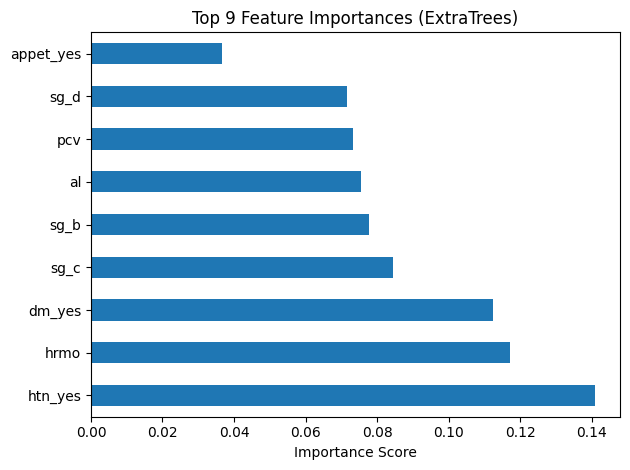

In [7]:
# Apply Feature Importance selector with top 9 features
fi_feat, selected_cols = feature_importance_selector(indep_X, dep_Y, 8)
print("Selected features:", list(selected_cols))

# Plot feature importances
from sklearn.ensemble import ExtraTreesClassifier
model = ExtraTreesClassifier(n_estimators=100, random_state=0)
model.fit(indep_X, dep_Y)
feat_imp = pd.Series(model.feature_importances_, index=indep_X.columns)
feat_imp.nlargest(9).plot(kind='barh')
plt.title('Top 9 Feature Importances (ExtraTrees)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

acclog   = []
accsvml  = []
accsvmnl = []
accknn   = []
accnav   = []
accdes   = []
accrf    = []


In [8]:
X_train, X_test, y_train, y_test = split_scalar(fi_feat, dep_Y)

classifier, Accuracy, report, X_test, y_test, cm = logistic(X_train, y_train, X_test)
acclog.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = svm_linear(X_train, y_train, X_test)
accsvml.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = svm_NL(X_train, y_train, X_test)
accsvmnl.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = knn(X_train, y_train, X_test)
accknn.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = Navie(X_train, y_train, X_test)
accnav.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = Decision(X_train, y_train, X_test)
accdes.append(Accuracy)

classifier, Accuracy, report, X_test, y_test, cm = random(X_train, y_train, X_test)
accrf.append(Accuracy)

result = fi_Classification(acclog, accsvml, accsvmnl, accknn, accnav, accdes, accrf)


In [6]:
result
#9

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
FeatureImportance,1.0,0.98,1.0,0.98,0.99,1.0,1.0


In [9]:
result
#8

,Logistic,SVMl,SVMnl,KNN,Navie,Decision,Random
FeatureImportance,0.99,0.99,0.99,0.96,0.98,0.99,0.99


When the numbers of the feature is 9 , we got the best performence